# 05_Feature_Importance: 特徴量重要度とSHAP分析

このノートブックでは、3d・5dモデルが何を根拠に予測しているかをGain-based ImportanceとSHAPを用いて分析します。

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import sys
import os

# src読み込み用パス設定
sys.path.append('..')
from src.processing import load_and_clean_data
from src.features import generate_features
from src.pooling import pool_boj_data
from src.modeling import walk_forward_validation

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 6)

/Users/nishiharahiroto/Documents/programs/BOJ_analysis/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. データ準備とモデル取得

In [2]:
excel_path = '../data/BOJ_data.xlsx'
meeting_path = '../data/BOJ_meeting_history.csv'

df_clean = load_and_clean_data(excel_path, meeting_path)
df_feat = generate_features(df_clean)
df_pooled = pool_boj_data(df_feat)

horizons = [3, 5]
models_data = {}
start_date = '2024-01-01'

for h in horizons:
    target_col = f'Target_{h}d'
    print(f"\n--- Training Final Fold for {target_col} ---")
    res, model, X_test, y_test, X_train = walk_forward_validation(
        df_pooled, target_col, start_date=start_date, return_model=True
    )
    models_data[h] = {
        'model': model,
        'X_test': X_test,
        'y_test': y_test,
        'X_train': X_train
    }


--- Training Final Fold for Target_3d ---
Training until validation scores don't improve for 100 rounds


Early stopping, best iteration is:
[1]	train's rmse: 0.0200739	valid's rmse: 0.0254237
Training until validation scores don't improve for 100 rounds


Early stopping, best iteration is:
[160]	train's rmse: 0.00799131	valid's rmse: 0.0176654
Training until validation scores don't improve for 100 rounds


Early stopping, best iteration is:
[32]	train's rmse: 0.0124954	valid's rmse: 0.0232448
Training until validation scores don't improve for 100 rounds


Early stopping, best iteration is:
[8]	train's rmse: 0.0177649	valid's rmse: 0.0265422
Training until validation scores don't improve for 100 rounds


...

Early stopping, best iteration is:
[28]	train's rmse: 0.0153039	valid's rmse: 0.0329993
Training until validation scores don't improve for 100 rounds


Early stopping, best iteration is:
[60]	train's rmse: 0.0121643	valid's rmse: 0.0291949
Training until validation scores don't improve for 100 rounds


Early stopping, best iteration is:
[493]	train's rmse: 0.00540228	valid's rmse: 0.060026
Training until validation scores don't improve for 100 rounds


Early stopping, best iteration is:
[2]	train's rmse: 0.0339092	valid's rmse: 0.0319881
Training until validation scores don't improve for 100 rounds


Early stopping, best iteration is:
[49]	train's rmse: 0.0164839	valid's rmse: 0.0380913


## 2. Gain-based Feature Importance

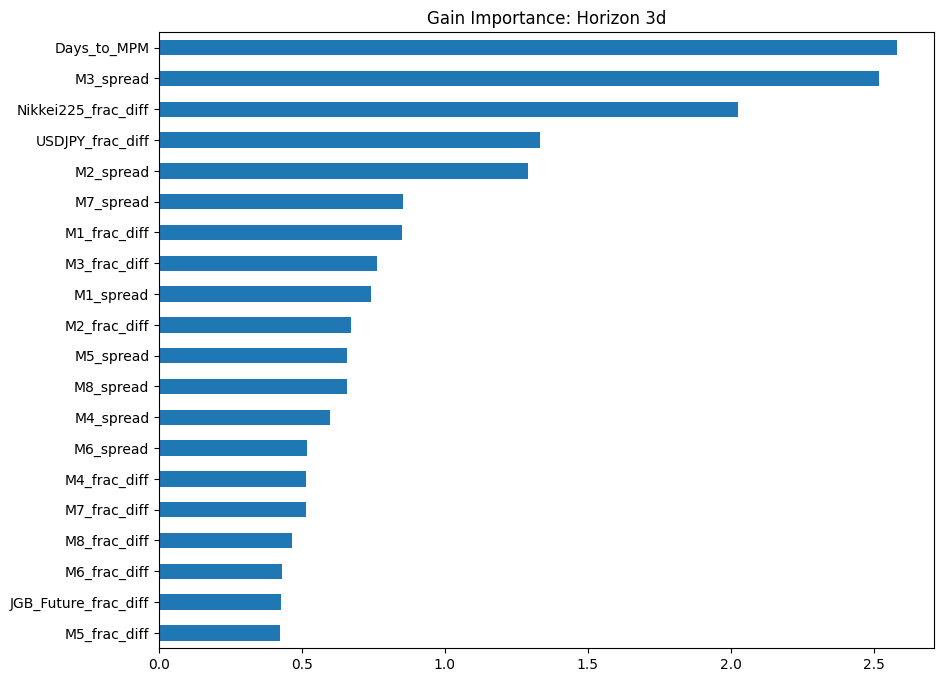

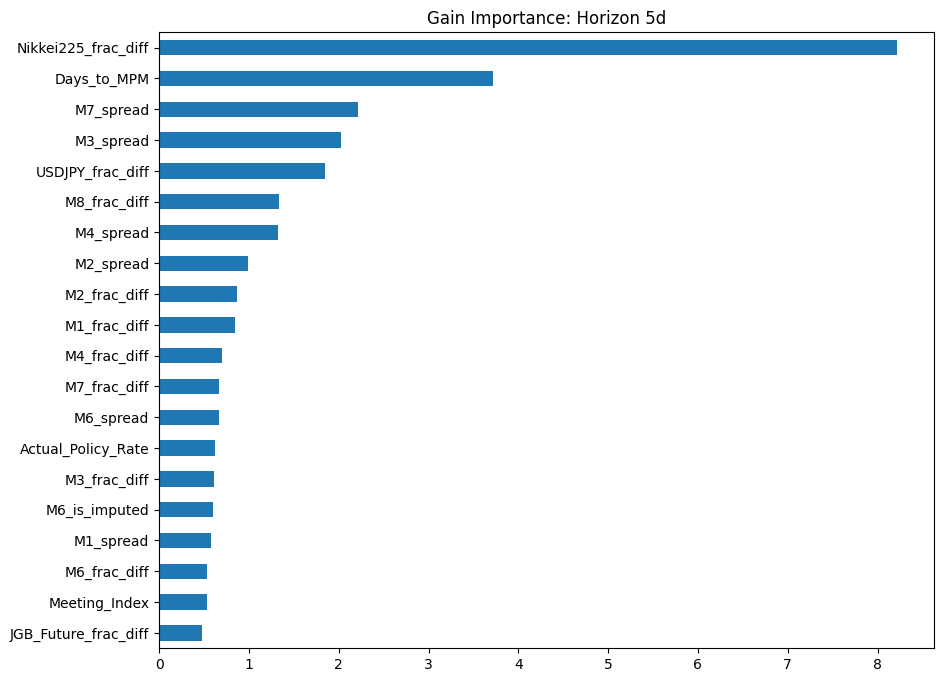

In [3]:
for h in horizons:
    model = models_data[h]['model']
    importance = pd.Series(
        model.feature_importance(importance_type='gain'),
        index=model.feature_name()
    ).sort_values(ascending=False)
    
    plt.figure(figsize=(10, 8))
    importance.head(20).plot(kind='barh').invert_yaxis()
    plt.title(f"Gain Importance: Horizon {h}d")
    plt.show()

## 3. SHAP Summary Plot

--- SHAP Summary Plot: Horizon 3d ---


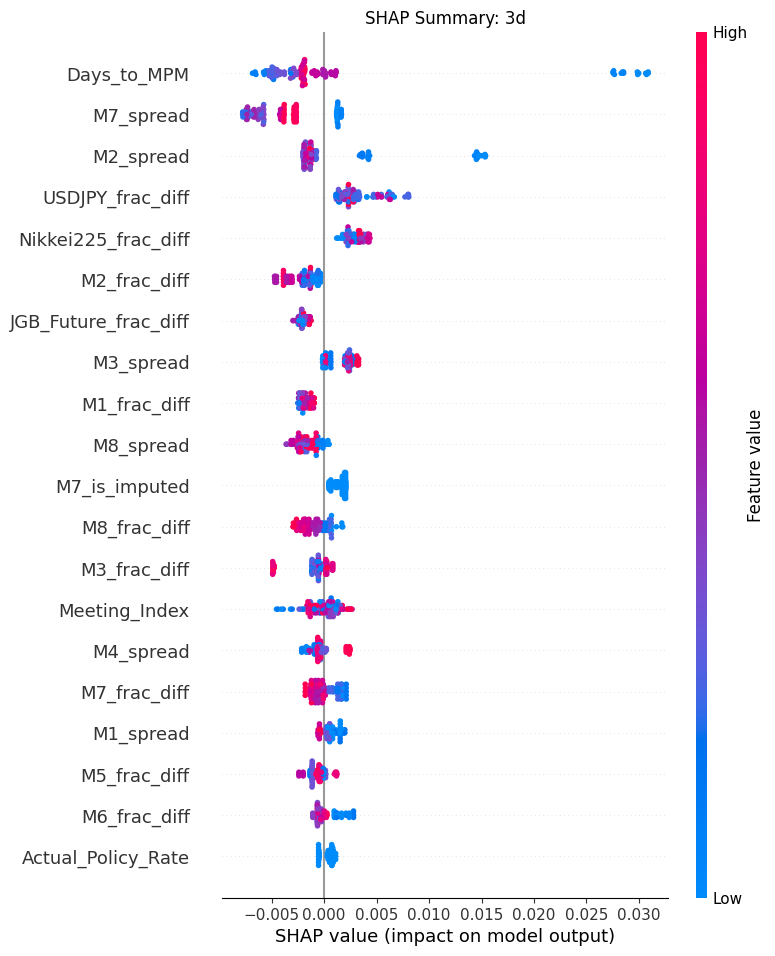

--- SHAP Summary Plot: Horizon 5d ---


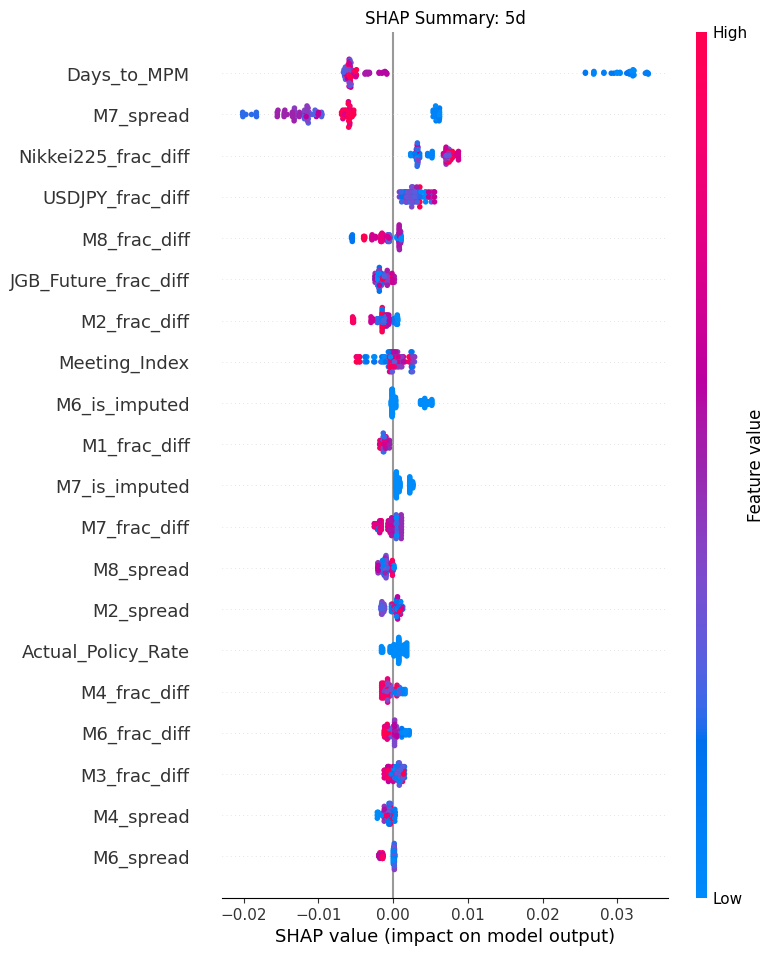

In [4]:
for h in horizons:
    print(f"--- SHAP Summary Plot: Horizon {h}d ---")
    model = models_data[h]['model']
    X_test = models_data[h]['X_test']
    
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_test)
    
    plt.figure()
    shap.summary_plot(shap_values, X_test, max_display=20, show=False)
    plt.title(f"SHAP Summary: {h}d")
    plt.show()

## 4. SHAP Dependence Plot (Top 3 Features)

<Figure size 1200x600 with 0 Axes>

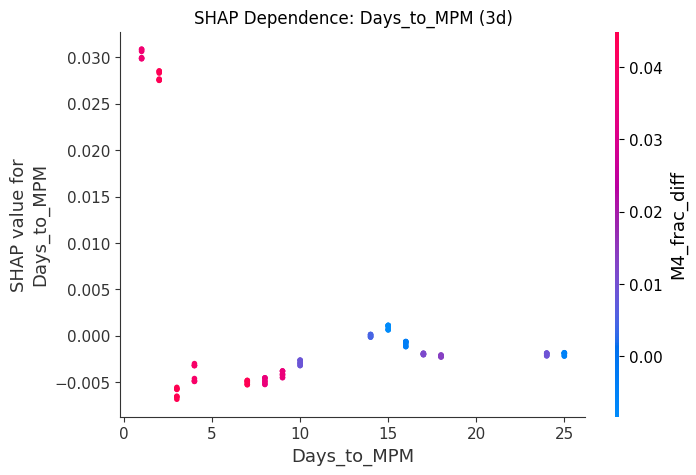

<Figure size 1200x600 with 0 Axes>

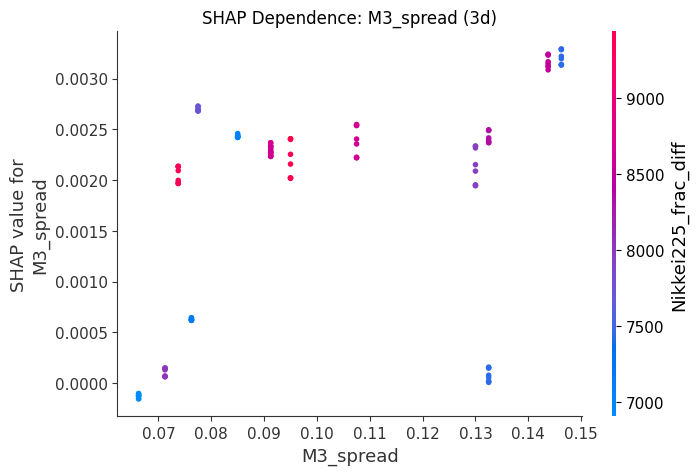

<Figure size 1200x600 with 0 Axes>

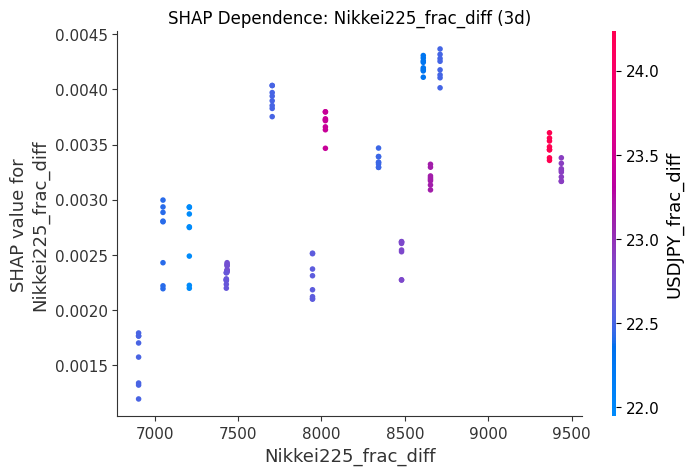

<Figure size 1200x600 with 0 Axes>

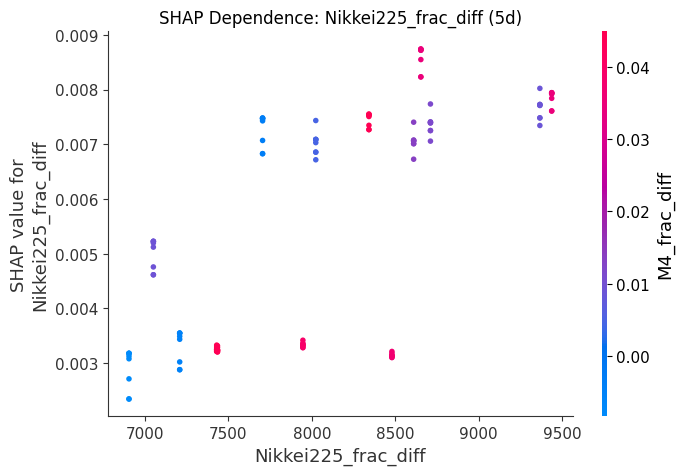

<Figure size 1200x600 with 0 Axes>

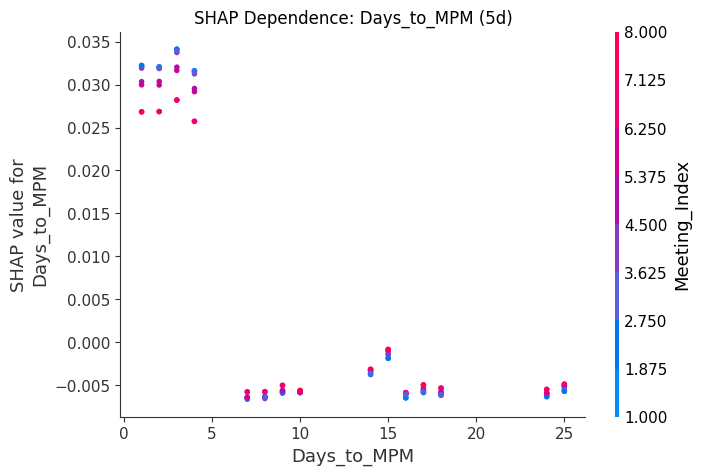

<Figure size 1200x600 with 0 Axes>

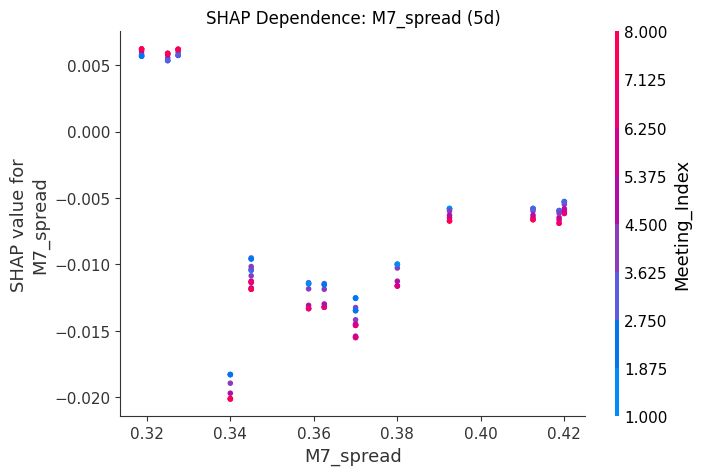

In [5]:
for h in horizons:
    model = models_data[h]['model']
    X_test = models_data[h]['X_test']
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_test)
    
    # Gain重要度の上位3つを取得
    importance = pd.Series(
        model.feature_importance(importance_type='gain'),
        index=model.feature_name()
    ).sort_values(ascending=False)
    top_features = importance.head(3).index.tolist()
    
    for feat in top_features:
        plt.figure()
        shap.dependence_plot(feat, shap_values, X_test, show=False)
        plt.title(f"SHAP Dependence: {feat} ({h}d)")
        plt.show()